# Tutorial

## 00 - globals

In [1]:
import os
import stamp as st

In [2]:
slides = {
    1: {
        "exprmat": "exprMat_file.csv.gz",
        "metadata": "metadata_file.csv.gz",
        "fov_positions": "fov_positions_file.csv.gz",
    }
}
# optional filepath prefix
data_dir = "data"

In [3]:
os.makedirs(st.config["adata_dir"], exist_ok=True)

## 01 - Read

In [4]:
import pandas as pd
import scanpy as sc

In [5]:
samples_df = pd.read_table("data/sample2fov.csv", sep=",")
samples_df.sort_values(["slide", "fov_start"], inplace=True)

st.validate_input(slides, samples_df, data_dir)

samples_df

,Donor,Treatment,Timepoint,sample,slide,fov_start,fov_end
0,6,Medium,1h,Medium_1h_don6,1,1,9
1,5,Medium,1h,Medium_1h_don5,1,10,18
2,4,Medium,1h,Medium_1h_don4,1,19,27
3,3,Medium,1h,Medium_1h_don3,1,28,36
4,2,Medium,1h,Medium_1h_don2,1,37,45
...,...,...,...,...,...,...,...
91,5,NaCl+Taurine,24h,NaCl+Taurine_24h_don5,2,388,396
92,4,NaCl+Taurine,24h,NaCl+Taurine_24h_don4,2,397,405
93,3,NaCl+Taurine,24h,NaCl+Taurine_24h_don3,2,406,414
94,2,NaCl+Taurine,24h,NaCl+Taurine_24h_don2,2,415,423


In [6]:
adata_file = os.path.join(st.config["adata_dir"], "raw_data.h5ad")
st.read_cosmx(
    slides,
    samples_df,
    adata_file,
    # samples_df_columns=["Donor", "Treatment", "Timepoint"],
    # metadata_df_columns=[
    #     'nCount_RNA', 'nFeature_RNA', "nCount_negprobes", "nCount_falsecode", "Area.um2", "qcFlagsFOV"
    # ],
    # nrows=100,
    data_dir=data_dir,
    overwrite=False,
    verbose=True,
)

adata_file already exists and overwrite=False


'adatas/raw_data.h5ad'

In [7]:
adata = sc.read_h5ad(adata_file)
adata.obs

,fov,cell_ID,slide,slide-fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,...,errorCtPerCellEstimate,percOfDataFromErrorPerCell,qcFlagsFOV,cell,sample,Donor,Treatment,Timepoint,fov_start,fov_end
slide-fov-cell_ID,,,,,,,,,,,,,,,,,,,,,
1-1-17,1,17,1,1-1,3240,0.89,3792,840,65,73,...,97.281767,0.142455,Pass,c_2_1_17,Medium_1h_don6,6,Medium,1h,1,9
1-1-50,1,50,1,1-1,5656,0.85,3348,1026,105,89,...,97.281767,0.142455,Pass,c_2_1_50,Medium_1h_don6,6,Medium,1h,1,9
1-1-546,1,546,1,1-1,5500,0.98,3715,3090,87,85,...,97.281767,0.142455,Pass,c_2_1_546,Medium_1h_don6,6,Medium,1h,1,9
1-1-698,1,698,1,1-1,3604,0.87,3932,3467,77,67,...,97.281767,0.142455,Pass,c_2_1_698,Medium_1h_don6,6,Medium,1h,1,9
1-1-774,1,774,1,1-1,2604,0.82,893,3653,55,67,...,97.281767,0.142455,Pass,c_2_1_774,Medium_1h_don6,6,Medium,1h,1,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1-428-735,428,735,1,1-428,4188,0.92,2419,3332,79,73,...,61.534091,0.119327,Pass,c_2_428_735,Medium_4h_don3,3,Medium,4h,424,432
1-428-833,428,833,1,1-428,2932,0.94,2522,3986,65,61,...,61.534091,0.119327,Pass,c_2_428_833,Medium_4h_don3,3,Medium,4h,424,432
1-429-8,429,8,1,1-429,2936,0.85,869,90,67,57,...,94.791667,0.178882,Pass,c_2_429_8,Medium_4h_don3,3,Medium,4h,424,432


## 02 - QC

In [8]:
import matplotlib.pyplot as plt

In [9]:
st.pp.gene_qc(adata)
adata.var

,is_negctrl,is_sysctrl,nCell,pctCell,nTranscript,meanTranscript,signal2noise
ABCB7,False,False,45,2.25,49,0.0245,NaN
ABCB8,False,False,110,5.50,118,0.0590,NaN
ABCC1,False,False,67,3.35,72,0.0360,NaN
ABCC4,False,False,50,2.50,54,0.0270,NaN
ABCE1,False,False,148,7.40,161,0.0805,NaN
...,...,...,...,...,...,...,...
ZDHHC21,False,False,67,3.35,75,0.0375,NaN
ZFP36,False,False,572,28.60,800,0.4000,NaN
ZNF706,False,False,198,9.90,232,0.1160,NaN
ZNRF1,False,False,71,3.55,76,0.0380,NaN


In [10]:
st.pp.slide_qc(adata, slides, data_dir)
adata.uns["fov_metadata"]

,slide-fov,slide,fov,x,y,nCounts,nCell,meanCountsPerCell,nCount_negprobes,mean_NegProbe-CountsPerCell,nCount_falsecode,mean_FalseCode-CountsPerCell,meanCellSize,Failed_AtoMX_QC
0,1-1,1,1,256,145130,5556,7,793.714286,1,0.142857,32,4.571429,58.018832,0
1,1-2,1,2,4512,145130,6140,11,558.181818,2,0.181818,33,3.000000,45.164922,0
2,1-3,1,3,8768,145130,5061,4,1265.250000,3,0.750000,23,5.750000,91.449104,0
3,1-4,1,4,256,140874,8240,14,588.571429,2,0.142857,37,2.642857,45.700784,0
4,1-5,1,5,4512,140874,12586,19,662.421053,7,0.368421,74,3.894737,49.871777,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,1-425,1,425,63155,68921,666,2,333.000000,0,0.000000,1,0.500000,30.844722,0
347,1-427,1,427,58899,64665,956,3,318.666667,1,0.333333,3,1.000000,39.081555,0
348,1-428,1,428,63155,64665,2348,5,469.600000,1,0.200000,11,2.200000,48.113137,0
349,1-429,1,429,67411,64665,101,1,101.000000,0,0.000000,0,0.000000,42.476597,0


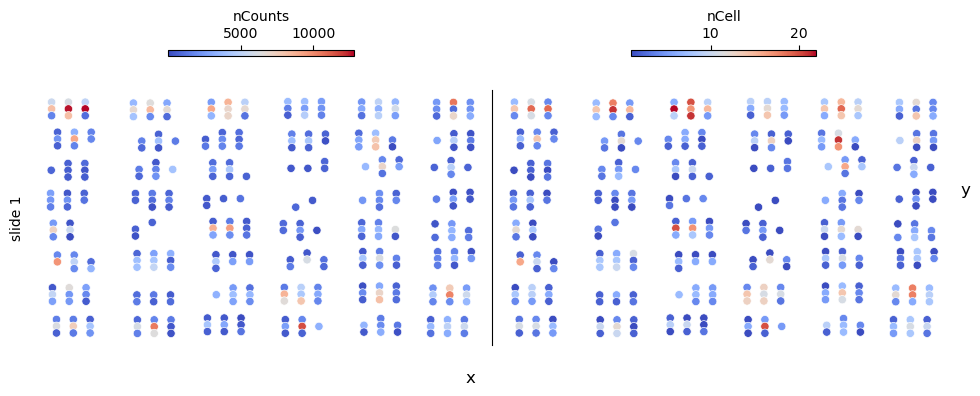

In [11]:
fig, axs = st.pl.slide_qc(adata, columns=["nCounts", "nCell"])
plt.show()

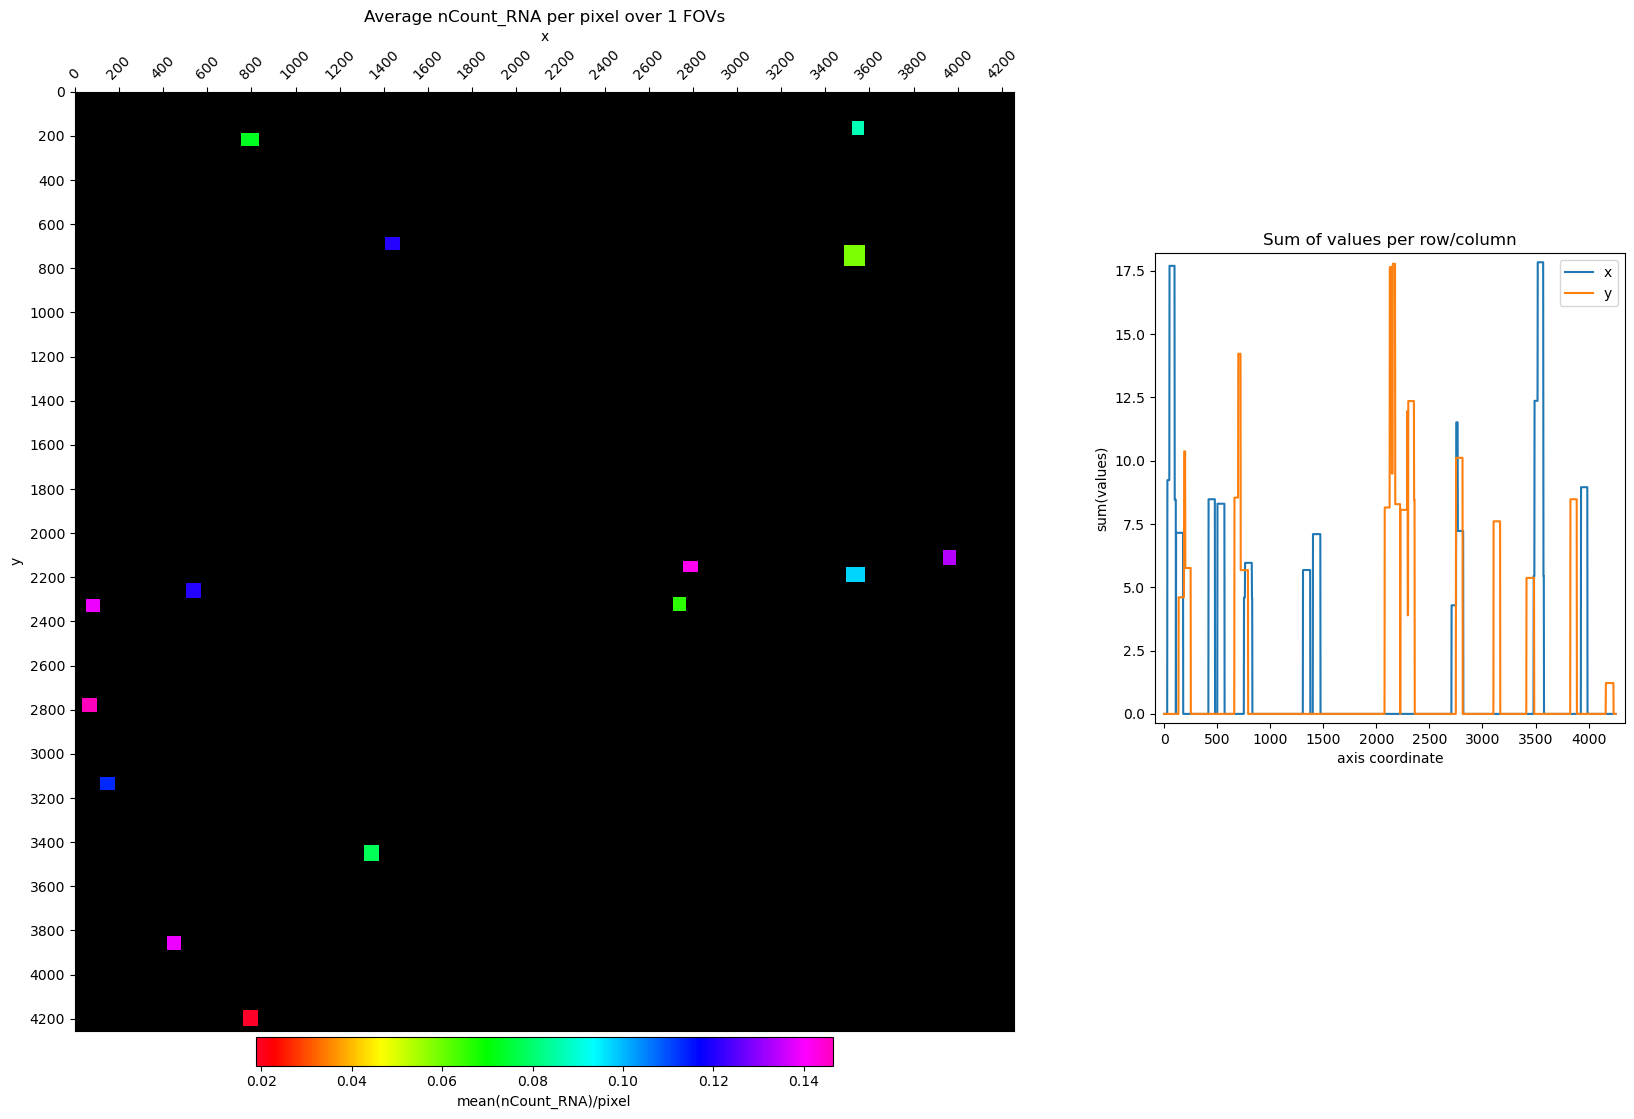

In [12]:
# plot nCount_RNA for a single FOV
idx = adata.obs[(adata.obs["slide-fov"] == "1-15")].index
fig, axs = st.pl.avg_per_pixel(adata[idx, :], column='nCount_RNA', log1p=False, fill_cell_area=True)
plt.show()

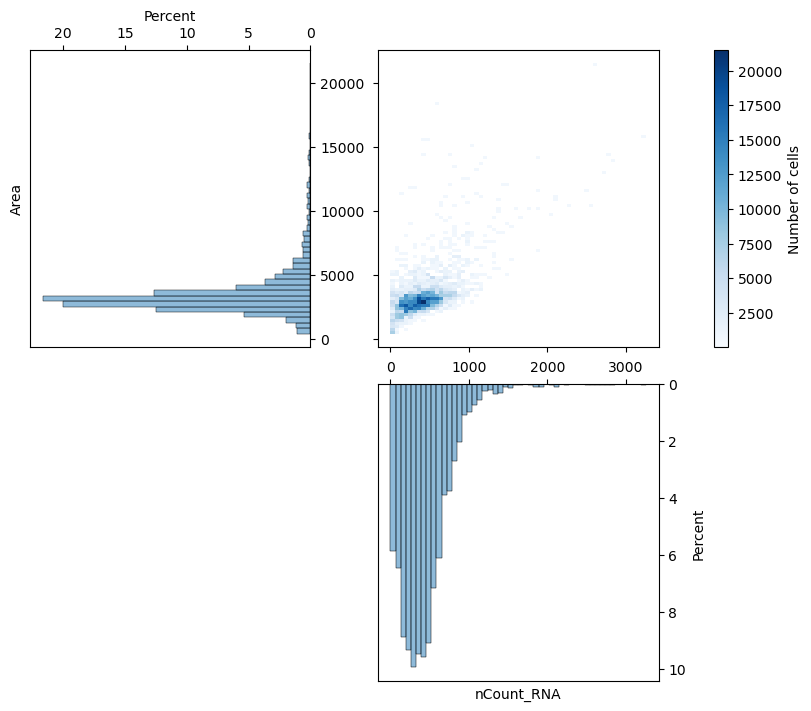

In [13]:
fig, axs = st.pl.correlations(adata, xcolumn="nCount_RNA", ycolumn="Area")
plt.show()

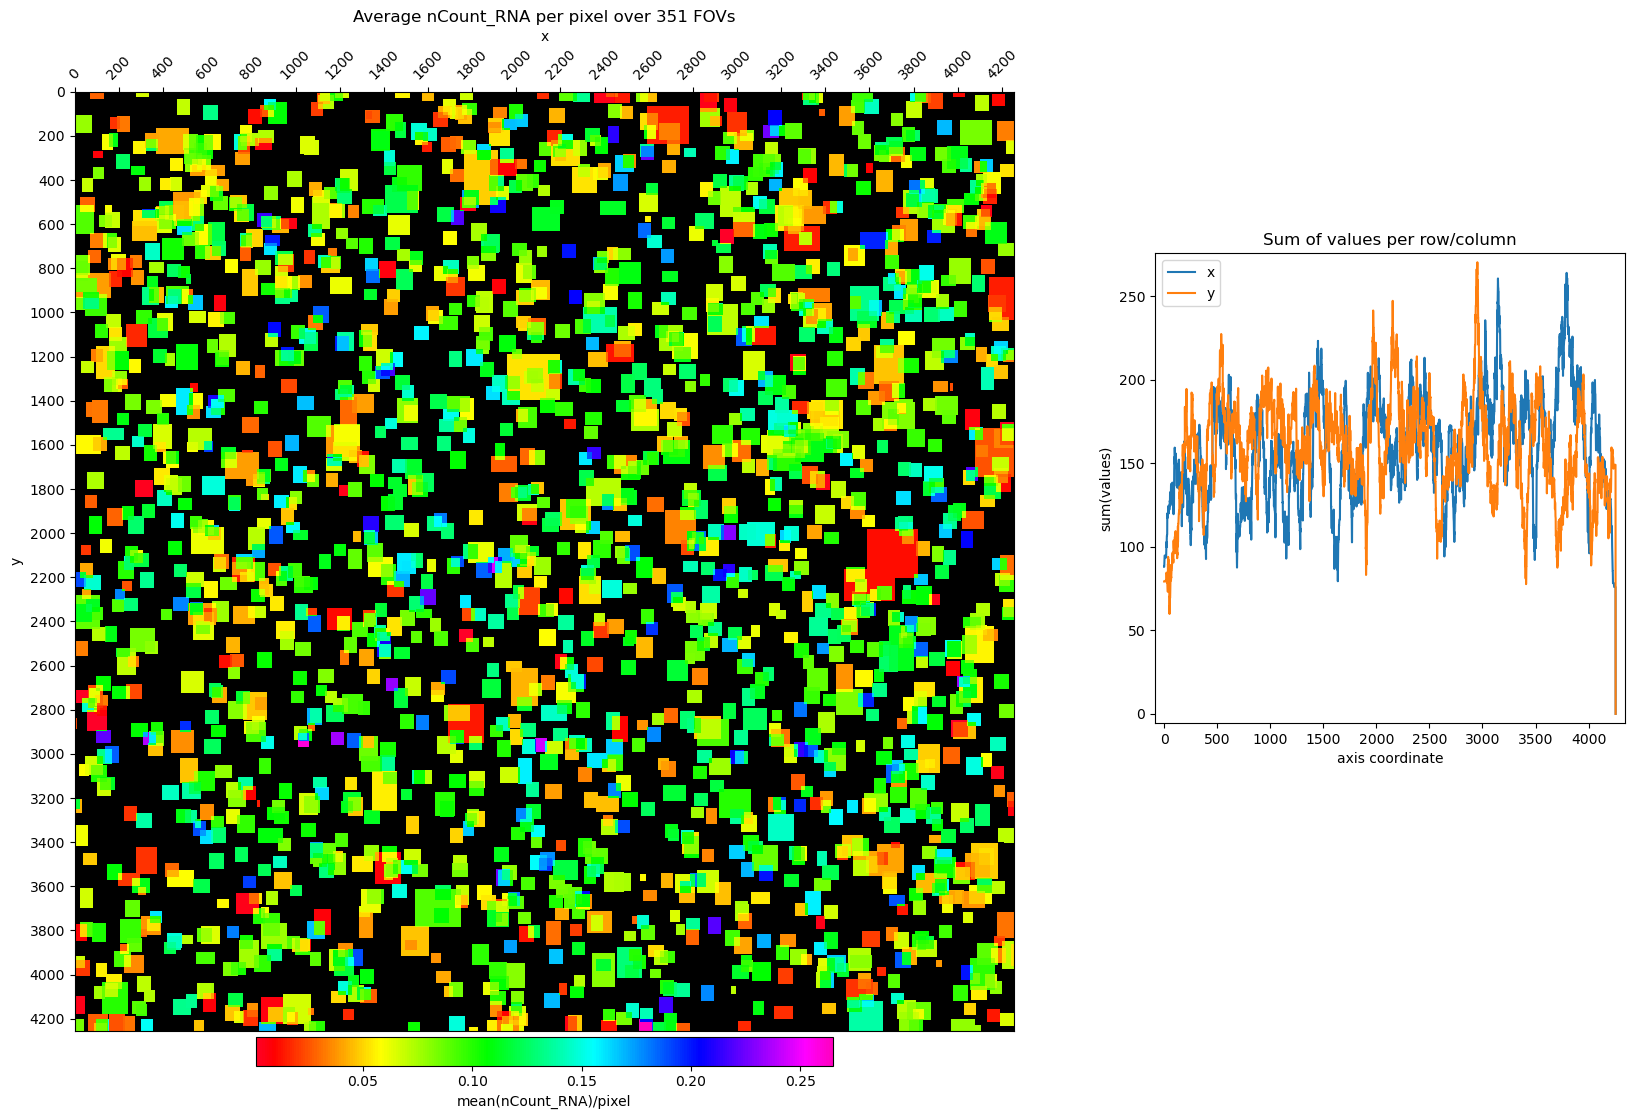

In [14]:
# plot nCount_RNA for the whole slide
fig, axs = st.pl.avg_per_pixel(adata, column='nCount_RNA', log1p=False, fill_cell_area=True)
plt.show()

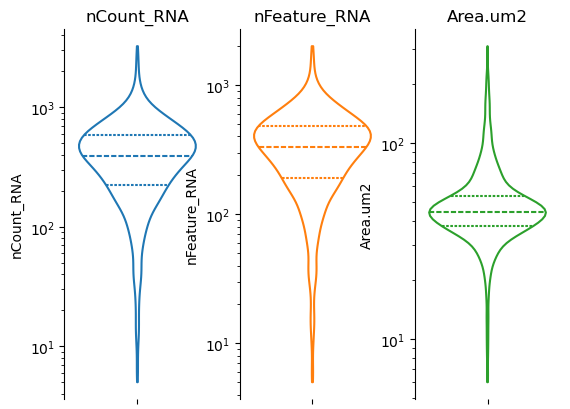

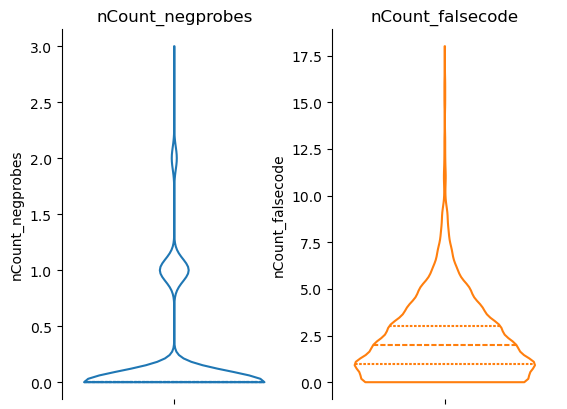

In [15]:
fig, axs = st.pl.violin(adata, ["nCount_RNA", "nFeature_RNA", "Area.um2"])
plt.show()
fig, axs = st.pl.violin(adata, ["nCount_negprobes", "nCount_falsecode"], log_scale=(False, False))
plt.show()

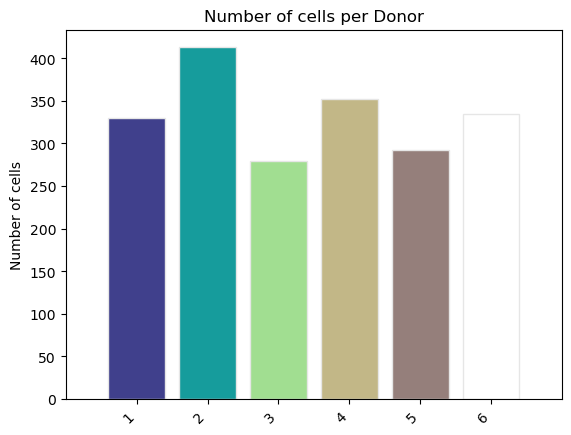

In [16]:
fig, ax = st.pl.ncell_per_condition(adata, "Donor")
plt.show()

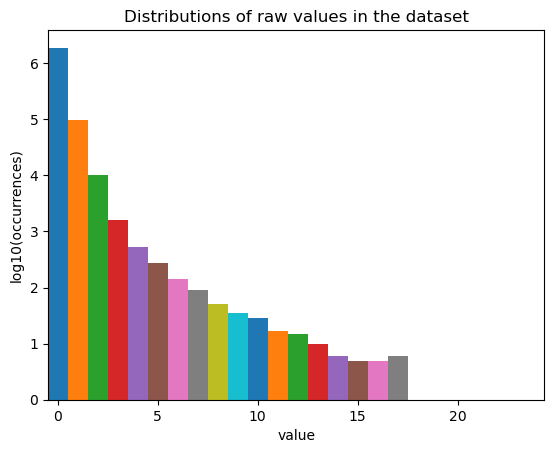

In [17]:
fig, ax = st.pl.value_distribution(adata)
plt.show()

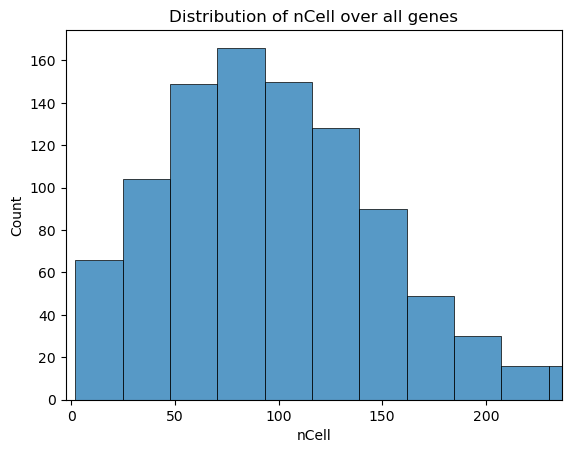

In [18]:
fig, ax = st.pl.column_distribution(adata, "nCell", axis=1)
plt.show()

## 03 - Filtering

In [19]:
import seaborn as sns

In [20]:
# TODO: better tutorial dataset
adata.var["signal2noise"] = 2

dist2edge_threshold=np.float64(50.0)


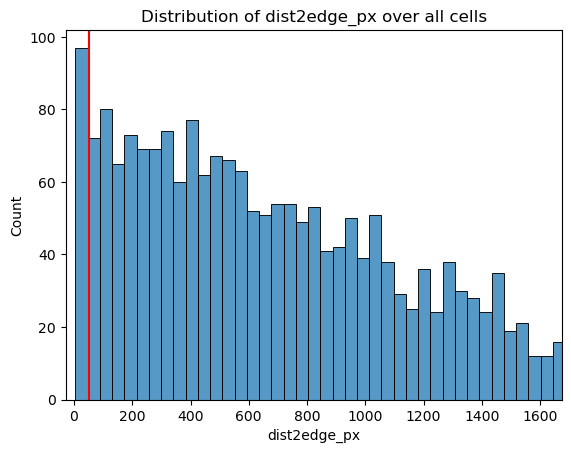

In [21]:
fig, ax = st.pl.column_distribution(adata, "dist2edge_px", plot_kwargs={"bins": 50})

# set a threshold & plot
dist2edge_threshold = adata.obs["dist2edge_px"].quantile(0.05)
print(f"{dist2edge_threshold=}")
ax.axvline(dist2edge_threshold, color="red")

plt.show()

In [22]:
adata = st.pp.filter_genes(adata, ncell_min=10)
adata = st.pp.filter_cells(adata, dist2edge_px_min=dist2edge_threshold)

55 genes filtered out, 945 genes remaining.
919 cells filtered out, 1_081 cells remaining.


In [23]:
st.pp.gene_qc_postfilter(adata)
adata.var[["nCell", "nCell_postfilter", "pctCell", "pctCell_postfilter"]]

,nCell,nCell_postfilter,pctCell,pctCell_postfilter
ABCB7,45,27,2.25,2.50
ABCB8,110,67,5.50,6.20
ABCC1,67,40,3.35,3.70
ABCC4,50,28,2.50,2.59
ABCE1,148,91,7.40,8.42
...,...,...,...,...
ZDHHC21,67,40,3.35,3.70
ZFP36,572,357,28.60,33.02
ZNF706,198,118,9.90,10.92
ZNRF1,71,38,3.55,3.52


In [24]:
st.pp.cell_qc_postfilter(adata)
adata.obs[["nFeature_RNA", "nFeature_RNA_postfilter", "nCount_RNA", "nCount_RNA_postfilter"]]

,nFeature_RNA,nFeature_RNA_postfilter,nCount_RNA,nCount_RNA_postfilter
slide-fov-cell_ID,,,,
1-1-546,1001,142,1373,183
1-1-774,231,40,267,42
1-1-930,740,112,1029,147
1-2-228,419,68,503,74
1-2-352,574,89,780,117
...,...,...,...,...
1-428-227,252,39,284,41
1-428-703,333,60,395,65
1-428-735,348,50,419,55


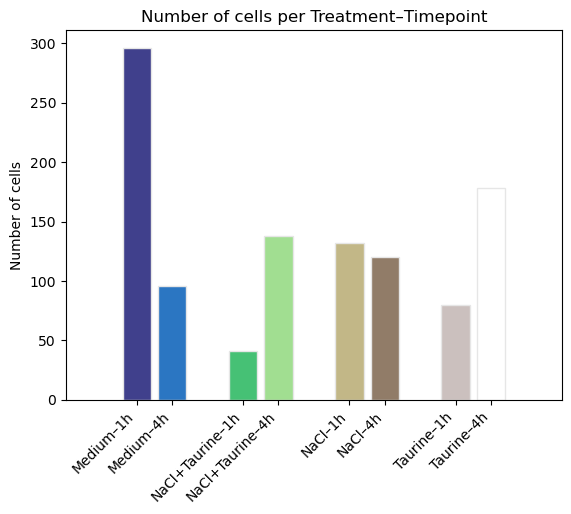

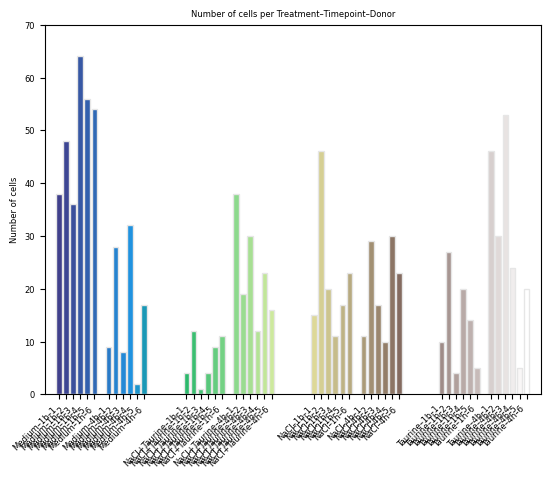

In [25]:
fig, ax = st.pl.ncell_per_condition(
    adata,
    columns = ["Treatment", "Timepoint"],
    offset_between_conditions = 1,
)
plt.show()

fig, ax = st.pl.ncell_per_condition(
    adata,
    columns = ["Treatment", "Timepoint", "Donor"],
    offset_between_conditions = [5, 1],
    text_kwargs={"size": 6},
)
plt.show()

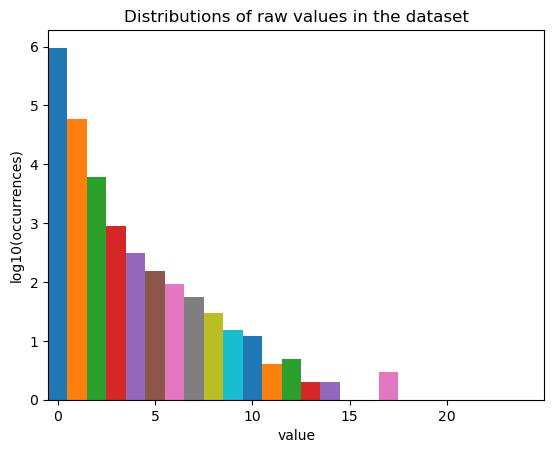

In [26]:
fig, ax = st.pl.value_distribution(adata)
plt.show()

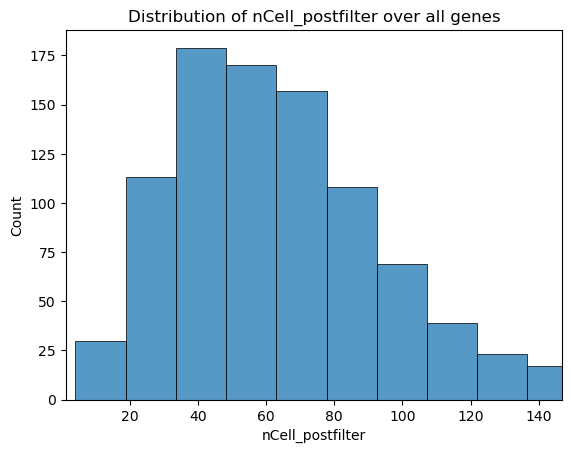

In [27]:
fig, ax = st.pl.column_distribution(adata, "nCell_postfilter", axis=1)
plt.show()

# 04 - Binarize

In [28]:
st.pp.binarize(adata)
adata_file = os.path.join(st.config["adata_dir"], "filtered.h5ad")
adata.write_h5ad(adata_file)

binary layer set as adata.X


In [29]:
adata.layers

Layers with keys: counts, binary

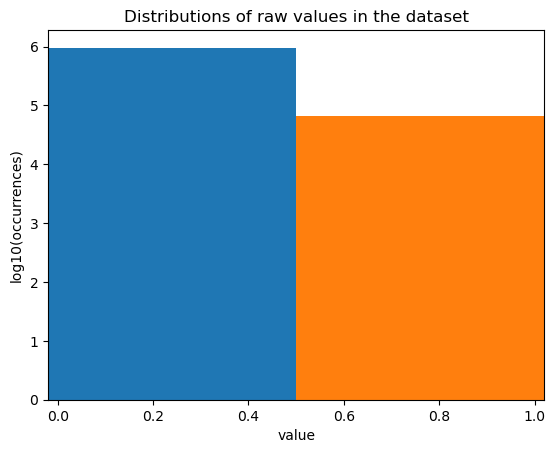

In [30]:
fig, ax = st.pl.value_distribution(adata, min_quantile=0.00, max_quantile=1.00)
plt.show()

# 05 - Dimensionality reduction

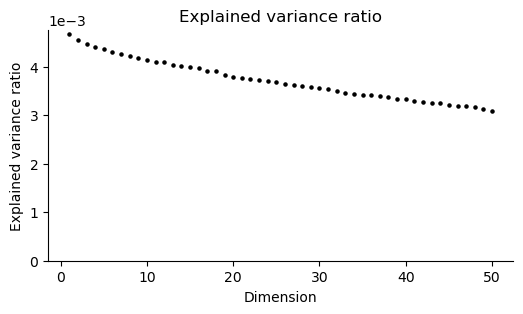

In [31]:
st.pp.dim_red(adata)
fig, ax = st.pl.scree(adata)
plt.show()

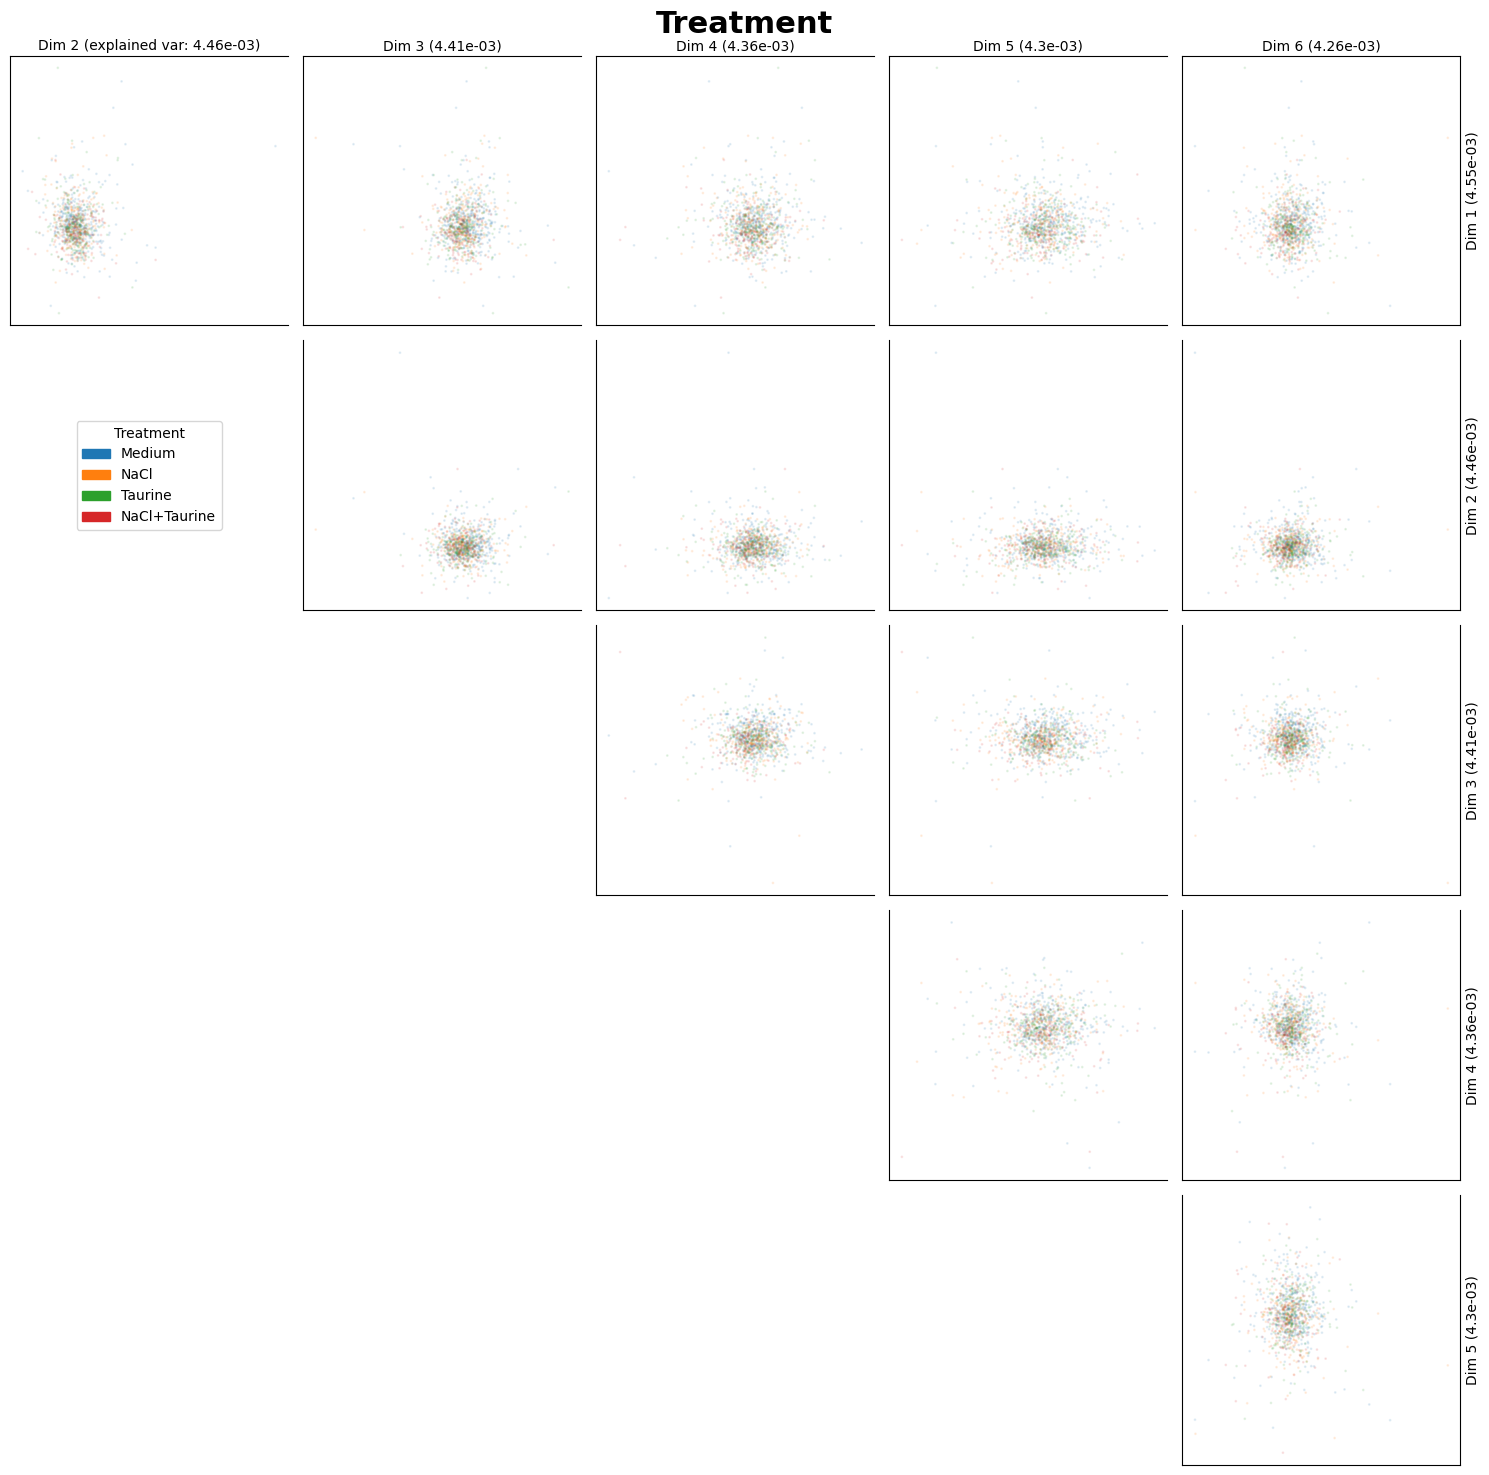

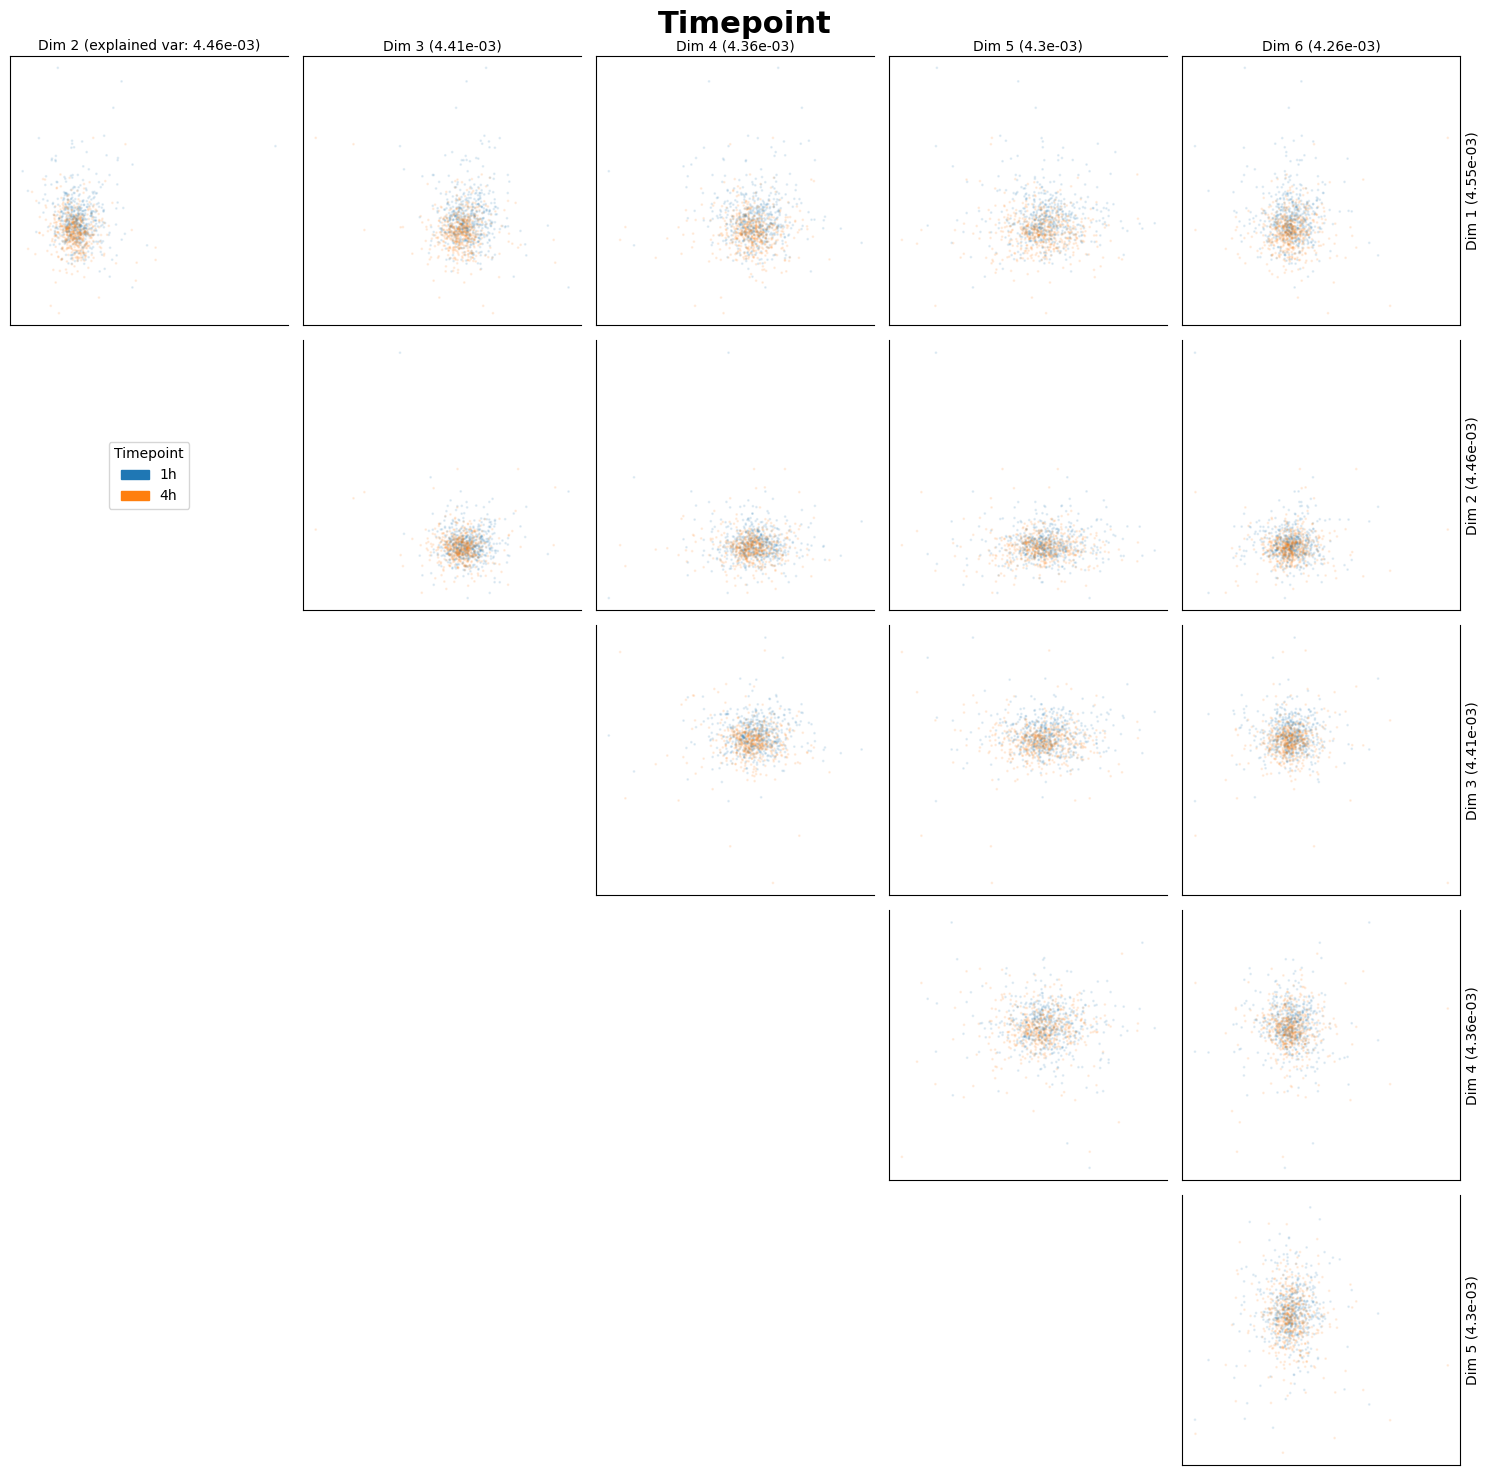

In [32]:
st.pl.dim_red(
    adata, 
    columns=["Treatment", "Timepoint"],
)

In [33]:
sc.pp.neighbors(
    adata,
    use_rep="X_svd",
    key_added="neighbors_svd",
)

In [34]:
sc.tl.umap(
    adata,
    neighbors_key="neighbors_svd",
    key_added="umap_svd",
)

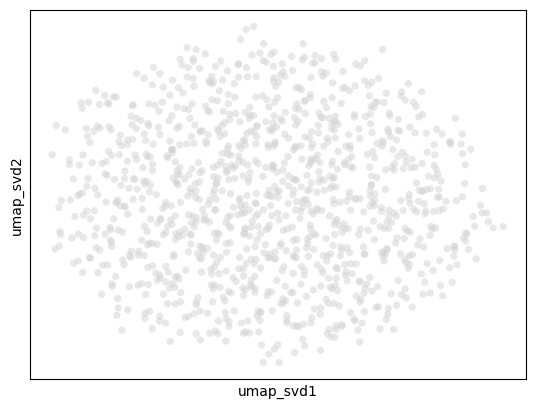

In [35]:
sc.pl.embedding(
    adata,
    basis="umap_svd",
    alpha=0.5,
)

# 06 - Clustering

In [36]:
st.pp.knn_count_smoothing(adata)

KNN_binary_mean layer set as adata.X


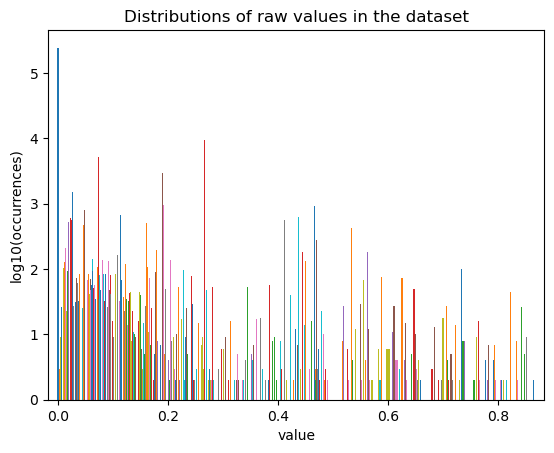

In [37]:
fig, ax = st.pl.value_distribution(adata, layer = "KNN_binary_mean")
plt.show()

In [38]:
markerdict = {
    "T_cells": [
        "CD3D", "CD3E", "TRBC1",
        "CD4", "IL7R", "CD8A", "CD8B",
    ],
    "B_cells": [
        "MS4A1", "CD79A", "CD79B", "CD37"
    ],
    "NK_cells": [
        "NKG7", "GNLY", "KLRD1", "FCGR3A"
    ],
    "Monocytes_Macrophages": [
        "LYZ", "LST1", "S100A8", "S100A9",
        "CTSD", "CST3", "LGALS3",
        "CD14", "CD68"
    ],
    "Dendritic_cells": [
        "FCER1A", "CST3", "CLEC10A", "CD1C"
    ]
}

for ctype in sorted(markerdict):
    for marker in set(markerdict[ctype]):
        if marker not in adata.var_names:
            print(f"{ctype} marker gene '{marker}' is not present in adata.var_names (removing)")
            markerdict[ctype].remove(marker)
    if len(markerdict[ctype]) == 0:
        del markerdict[ctype]

B_cells marker gene 'CD37' is not present in adata.var_names (removing)
B_cells marker gene 'MS4A1' is not present in adata.var_names (removing)
B_cells marker gene 'CD79A' is not present in adata.var_names (removing)
B_cells marker gene 'CD79B' is not present in adata.var_names (removing)
Dendritic_cells marker gene 'CST3' is not present in adata.var_names (removing)
Dendritic_cells marker gene 'CD1C' is not present in adata.var_names (removing)
Dendritic_cells marker gene 'CLEC10A' is not present in adata.var_names (removing)
Dendritic_cells marker gene 'FCER1A' is not present in adata.var_names (removing)
Monocytes_Macrophages marker gene 'CTSD' is not present in adata.var_names (removing)
Monocytes_Macrophages marker gene 'CD68' is not present in adata.var_names (removing)
Monocytes_Macrophages marker gene 'CD14' is not present in adata.var_names (removing)
Monocytes_Macrophages marker gene 'LST1' is not present in adata.var_names (removing)
Monocytes_Macrophages marker gene 'S100A

T_cells


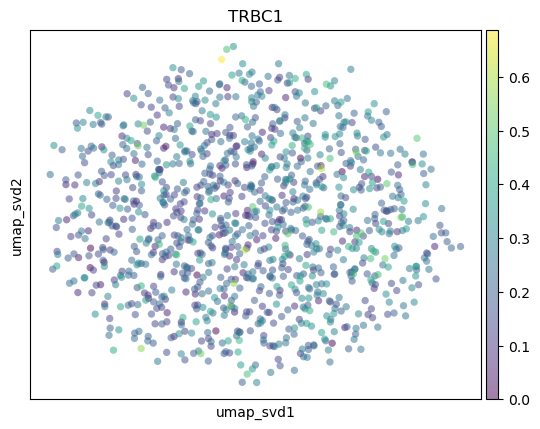

In [39]:
for ctype, markers in markerdict.items():
    if len(markers) == 0:
        continue
        
    print(ctype)
    sc.pl.embedding(
        adata,
        basis="umap_svd",
        color=markers,
        layer="KNN_binary_mean",
        ncols=3,
        alpha=0.5,
    )

In [40]:
res=0.7
key = f"leiden_res_{res:.2f}"
sc.tl.leiden(
    adata,
    resolution=res,
    neighbors_key="neighbors_svd",
    key_added=key,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42,
)

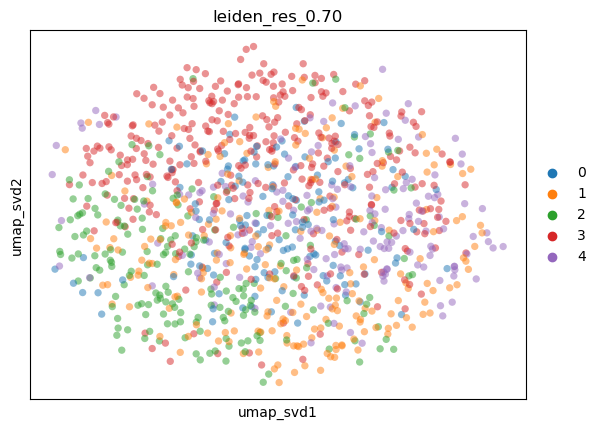

In [41]:
sc.pl.embedding(
    adata,
    basis="umap_svd",
    color=key,
    alpha=0.5,
)

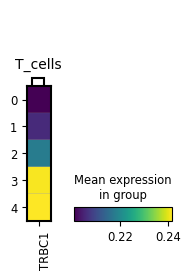

In [42]:
mp = sc.pl.MatrixPlot(
    adata,
    markerdict,
    groupby=key,
    layer="KNN_binary_mean",
    var_group_rotation=0,
)
ax = mp.get_axes()["mainplot_ax"]
_ = plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

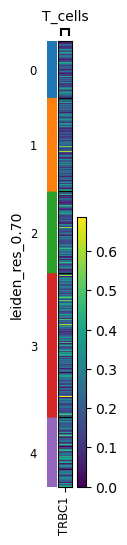

In [43]:
sc.pl.heatmap(
    adata, 
    markerdict,
    groupby=key,
    layer="KNN_binary_mean",
    var_group_rotation=0,
)

In [44]:
# TODO: redo
ctype_key = "celltype_lvl1"
cluster2ctype = {
    "0":"T_cells",
    "1":"Myeloid_cells",
    "2":"NK_cells",
    "3":"B_cells",
    "4":"Unknown",
}
adata.obs[ctype_key] = adata.obs[key].astype(str).replace(cluster2ctype).astype("category")

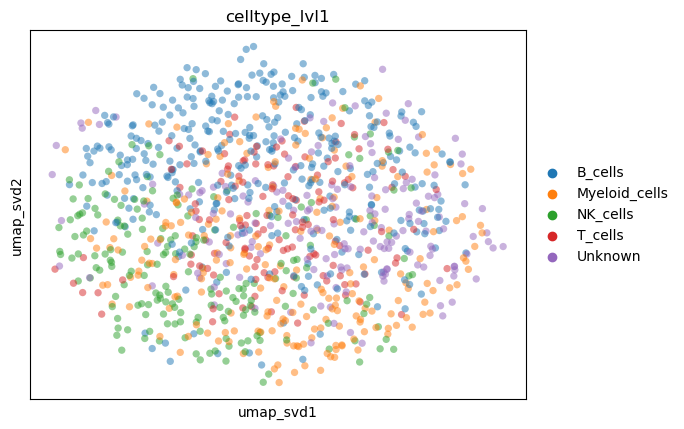

In [45]:
sc.pl.embedding(
    adata,
    basis="umap_svd",
    color=ctype_key,
    alpha=0.5,
)

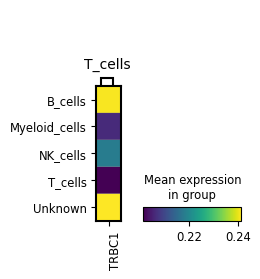

In [46]:
mp = sc.pl.MatrixPlot(
    adata,
    markerdict,
    groupby=ctype_key,
    layer="KNN_binary_mean",
    var_group_rotation=0,
)
ax = mp.get_axes()["mainplot_ax"]
_ = plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

In [47]:
df = st.pp.pseudobulk(
    adata,
    sample_column="sample",
    cluster_column=ctype_key,
    cluster="T_cells",
)
df

,Medium_1h_don1,Medium_1h_don2,Medium_1h_don3,Medium_1h_don4,Medium_1h_don5,Medium_1h_don6,Medium_4h_don1,Medium_4h_don2,Medium_4h_don3,Medium_4h_don4,...,NaCl_4h_don5,NaCl_4h_don6,Taurine_1h_don1,Taurine_1h_don2,Taurine_1h_don4,Taurine_4h_don1,Taurine_4h_don2,Taurine_4h_don3,Taurine_4h_don4,Taurine_4h_don6
ABCB7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABCB8,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
ABCC1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABCC4,0,0,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
ABCE1,0,0,1,1,1,5,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZDHHC21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZFP36,6,2,5,8,2,5,0,0,0,0,...,1,0,3,3,1,0,0,0,1,0
ZNF706,0,0,3,0,3,7,0,0,1,1,...,0,0,0,2,1,0,0,0,0,2
ZNRF1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
